# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [ ]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [ ]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [ ]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-06 10:24:21--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.173.161.58, 3.173.161.80, 3.173.161.10, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.173.161.58|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   256MB/s    in 1.3s    

2026-06-06 10:24:22 (256 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


In [ ]:
import numpy as np, tensorflow as tf

SEED, IMG_SIZE, BATCH = 42, (128, 128), 32
DATA_DIR = "cell_images"
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(SEED)

# Load EVERYTHING as one dataset (no subset split yet)
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="int", shuffle=True)            # shuffle=True mixes classes
class_names = full_ds.class_names
print("Classes:", class_names)

# Count batches, split 70 / 15 / 15
n_batches = tf.data.experimental.cardinality(full_ds).numpy()
n_train = int(0.70 * n_batches)
n_val   = int(0.15 * n_batches)

train_ds = full_ds.take(n_train)
val_ds   = full_ds.skip(n_train).take(n_val)
test_ds  = full_ds.skip(n_train + n_val)

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# CHECK — both numbers should be sizable, not [0, something]
y_true = np.concatenate([y.numpy() for _, y in test_ds])
print("Test set label counts:", np.bincount(y_true.astype(int)))
print("Total test samples:", len(y_true))

Found 27558 files belonging to 2 classes.
Classes: ['Parasitized', 'Uninfected']
Test set label counts: [2043 2091]
Total test samples: 4134



1. Frozen
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 64s 73ms/step - accuracy: 0.8670 - loss: 0.3015 - val_accuracy: 0.9222 - val_loss: 0.2167
Epoch 2/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9132 - loss: 0.2273 - val_accuracy: 0.9336 - val_loss: 0.1965
Epoch 3/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9210 - loss: 0.2085 - val_accuracy: 0.9351 - val_loss: 0.1891
Epoch 4/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9226 - loss: 0.2031 - val_accuracy: 0.9356 - val_loss: 0.1855
Epoch 5/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9243 - loss: 0.1991 - val_accuracy: 0.9375 - val_loss: 0.1852
Epoch 6/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9245 - loss: 0.1961 - val_accuracy: 0.9375 - val_loss: 0.1808
Epoch 7/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9250 - loss: 0.1960 - val_accuracy: 0.9365 - val_loss: 0.1808
Epoch 8/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 8s 1

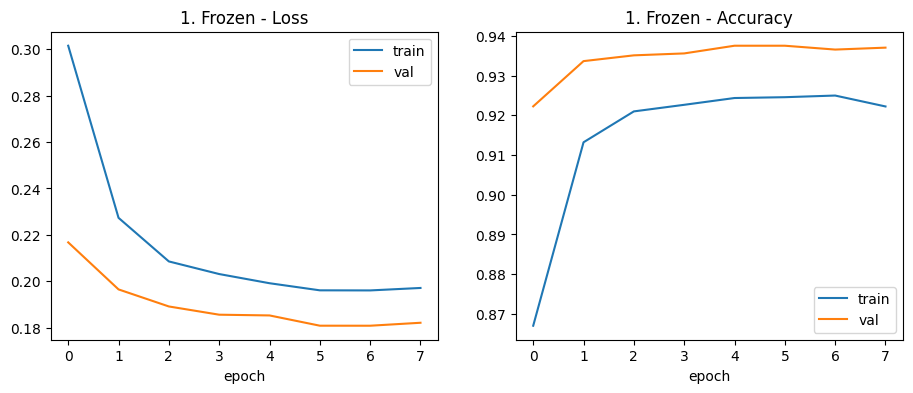

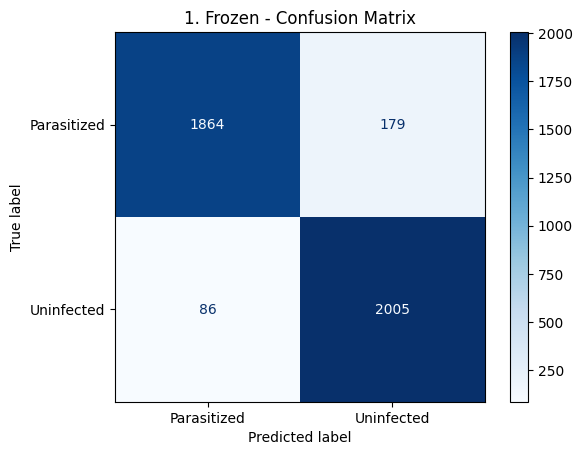

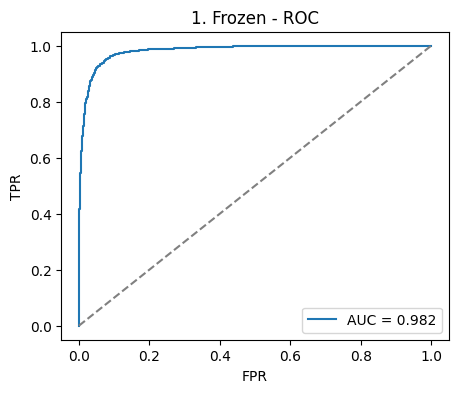


2. + Augmentation
Epoch 1/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.8577 - loss: 0.3281 - val_accuracy: 0.9019 - val_loss: 0.2527
Epoch 2/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.9002 - loss: 0.2509 - val_accuracy: 0.9000 - val_loss: 0.2409
Epoch 3/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9043 - loss: 0.2434 - val_accuracy: 0.9157 - val_loss: 0.2301
Epoch 4/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9074 - loss: 0.2365 - val_accuracy: 0.9172 - val_loss: 0.2289
Epoch 5/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.9067 - loss: 0.2388 - val_accuracy: 0.9191 - val_loss: 0.2262
Epoch 6/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.9092 - loss: 0.2336 - val_accuracy: 0.9196 - val_loss: 0.2297
Epoch 7/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.9099 - loss: 0.2320 - val_accuracy: 0.9142 - val_loss: 0.2316
Epoch 8/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9102 - loss

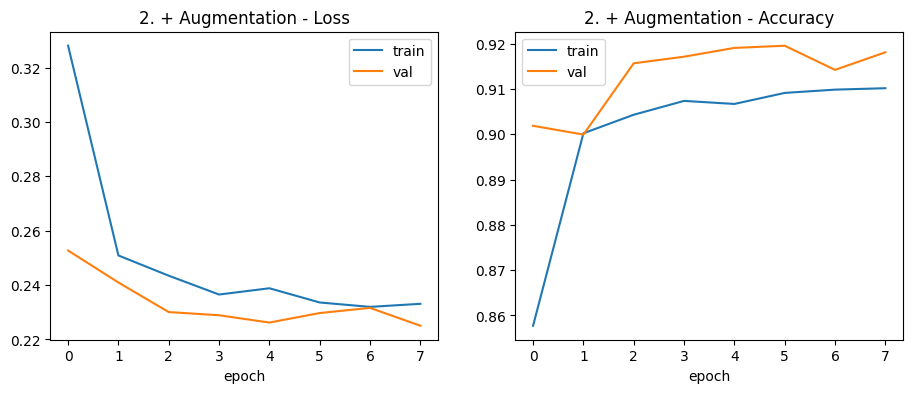

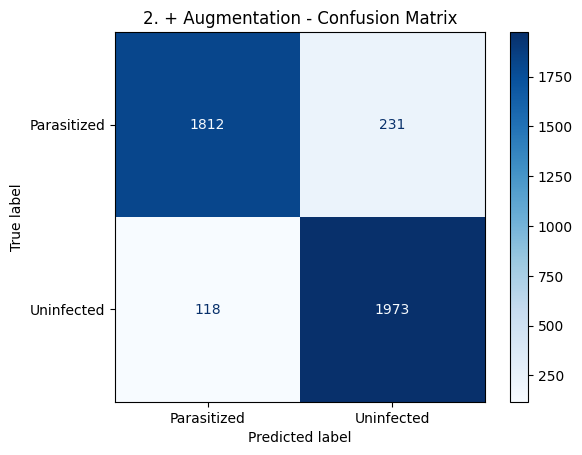

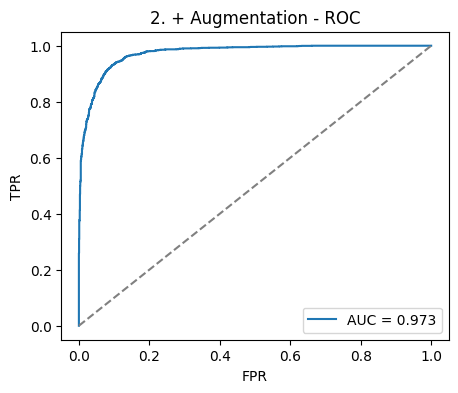


3. Lower LR 1e-4
Epoch 1/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7422 - loss: 0.5164 - val_accuracy: 0.8171 - val_loss: 0.3991
Epoch 2/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8310 - loss: 0.3806 - val_accuracy: 0.8454 - val_loss: 0.3467
Epoch 3/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8553 - loss: 0.3359 - val_accuracy: 0.8542 - val_loss: 0.3227
Epoch 4/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8724 - loss: 0.3080 - val_accuracy: 0.8699 - val_loss: 0.2990
Epoch 5/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8809 - loss: 0.2906 - val_accuracy: 0.8731 - val_loss: 0.2903
Epoch 6/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8856 - loss: 0.2813 - val_accuracy: 0.8803 - val_loss: 0.2782
Epoch 7/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8879 - loss: 0.2740 - val_accuracy: 0.8849 - val_loss: 0.2723
Epoch 8/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8945 - loss:

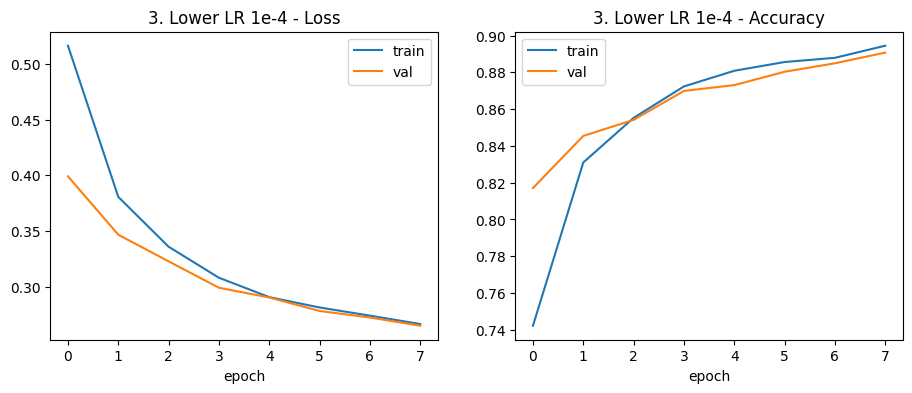

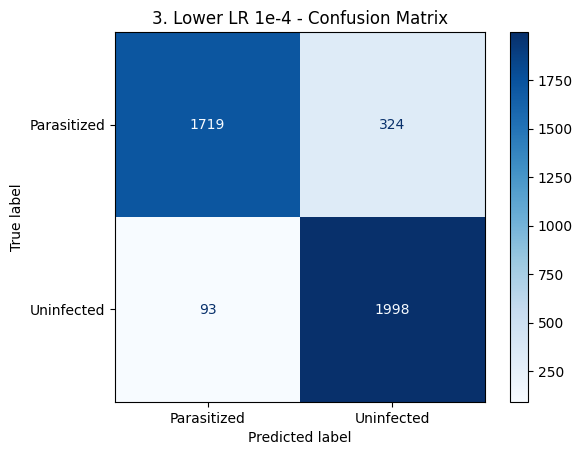

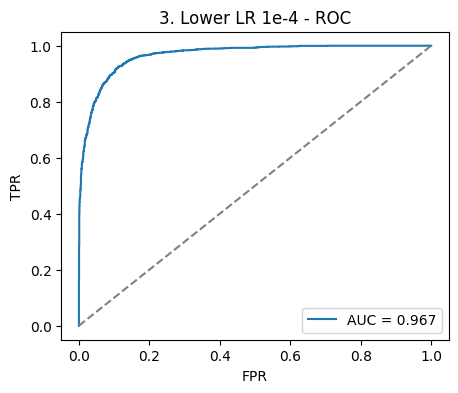


4. Fine-tune 20
Epoch 1/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.8458 - loss: 0.3474 - val_accuracy: 0.7078 - val_loss: 0.7167
Epoch 2/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9122 - loss: 0.2260 - val_accuracy: 0.8142 - val_loss: 0.4283
Epoch 3/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9254 - loss: 0.1975 - val_accuracy: 0.9021 - val_loss: 0.2263
Epoch 4/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9314 - loss: 0.1801 - val_accuracy: 0.9152 - val_loss: 0.2024
Epoch 5/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.9371 - loss: 0.1723 - val_accuracy: 0.9193 - val_loss: 0.1919
Epoch 6/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9388 - loss: 0.1659 - val_accuracy: 0.9278 - val_loss: 0.1762
Epoch 7/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9410 - loss: 0.1612 - val_accuracy: 0.9312 - val_loss: 0.1699
Epoch 8/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.9442 - loss: 

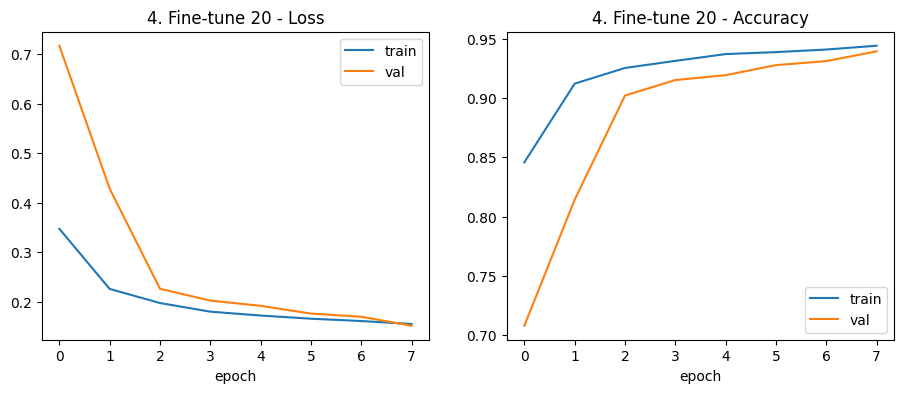

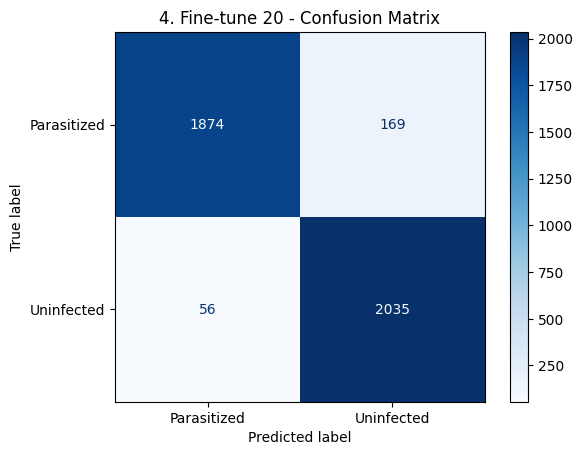

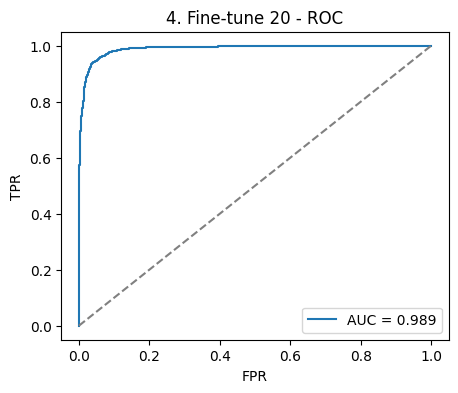


5. Fine-tune 40
Epoch 1/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.8585 - loss: 0.3227 - val_accuracy: 0.7248 - val_loss: 0.6726
Epoch 2/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.9294 - loss: 0.1922 - val_accuracy: 0.9060 - val_loss: 0.2297
Epoch 3/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9412 - loss: 0.1652 - val_accuracy: 0.9472 - val_loss: 0.1456
Epoch 4/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9467 - loss: 0.1490 - val_accuracy: 0.9477 - val_loss: 0.1424
Epoch 5/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.9486 - loss: 0.1440 - val_accuracy: 0.9503 - val_loss: 0.1343
Epoch 6/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.9510 - loss: 0.1392 - val_accuracy: 0.9501 - val_loss: 0.1313
Epoch 7/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.9532 - loss: 0.1332 - val_accuracy: 0.9535 - val_loss: 0.1287
Epoch 8/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.9558 - loss: 

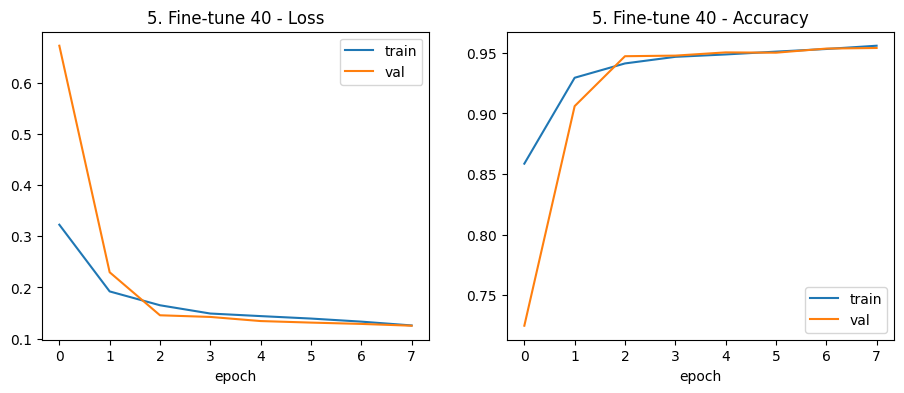

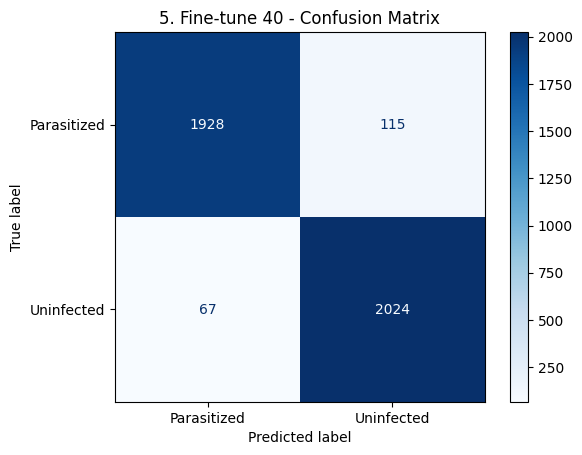

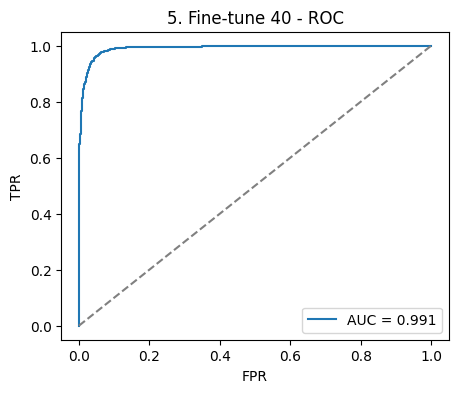


6. + Dropout 0.4
Epoch 1/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.8302 - loss: 0.3697 - val_accuracy: 0.8343 - val_loss: 0.3528
Epoch 2/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9053 - loss: 0.2426 - val_accuracy: 0.8692 - val_loss: 0.2924
Epoch 3/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9198 - loss: 0.2097 - val_accuracy: 0.8997 - val_loss: 0.2329
Epoch 4/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.9291 - loss: 0.1937 - val_accuracy: 0.9186 - val_loss: 0.1965
Epoch 5/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.9312 - loss: 0.1882 - val_accuracy: 0.9324 - val_loss: 0.1711
Epoch 6/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9334 - loss: 0.1771 - val_accuracy: 0.9244 - val_loss: 0.1829
Epoch 7/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.9384 - loss: 0.1692 - val_accuracy: 0.9382 - val_loss: 0.1611
Epoch 8/8
603/603 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9420 - loss:

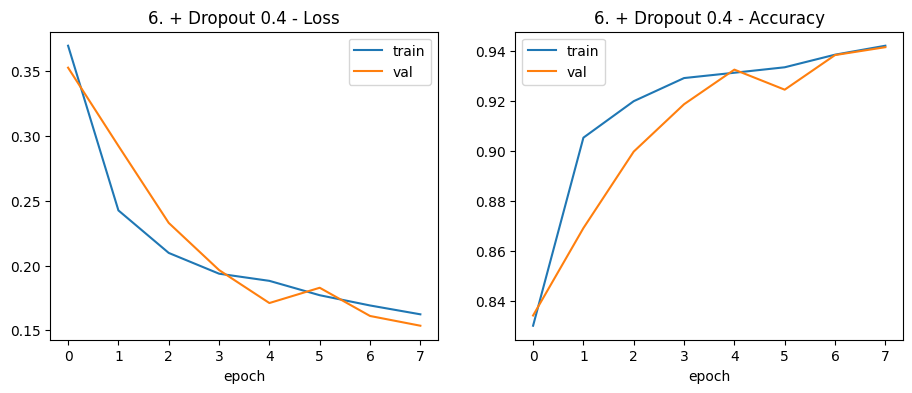

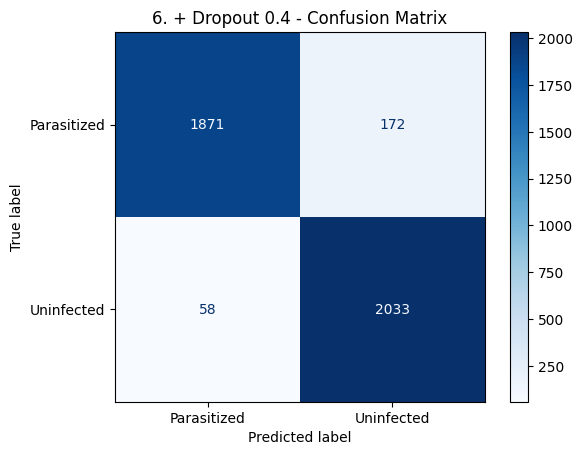

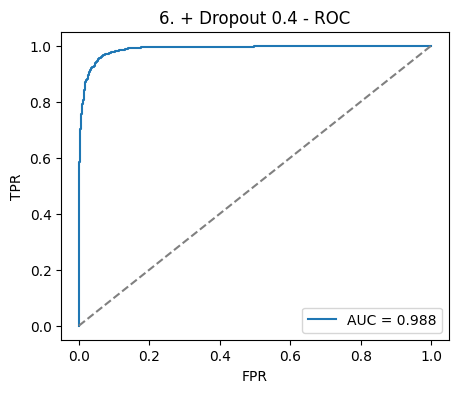


7. Best combo
Epoch 1/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.8341 - loss: 0.3656 - val_accuracy: 0.8055 - val_loss: 0.4254
Epoch 2/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9082 - loss: 0.2356 - val_accuracy: 0.8699 - val_loss: 0.2869
Epoch 3/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9220 - loss: 0.2038 - val_accuracy: 0.8934 - val_loss: 0.2437
Epoch 4/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9309 - loss: 0.1860 - val_accuracy: 0.9285 - val_loss: 0.1874
Epoch 5/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9335 - loss: 0.1816 - val_accuracy: 0.9348 - val_loss: 0.1754
Epoch 6/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.9364 - loss: 0.1737 - val_accuracy: 0.9334 - val_loss: 0.1701
Epoch 7/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9409 - loss: 0.1614 - val_accuracy: 0.9281 - val_loss: 0.1818
Epoch 8/12
603/603 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.9409 - 

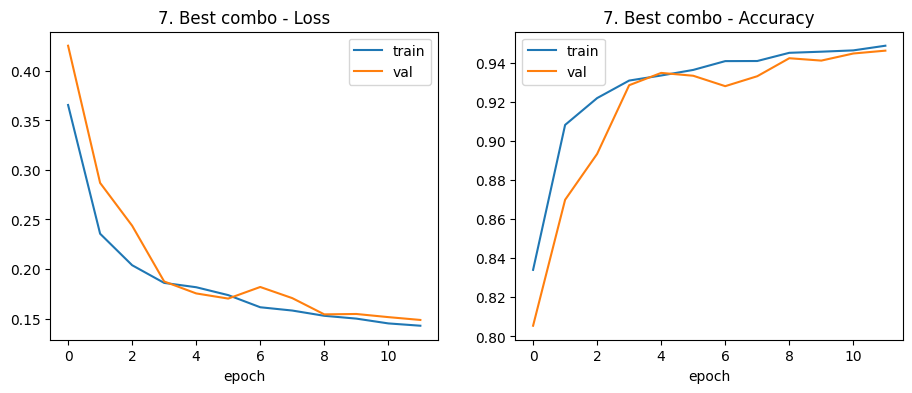

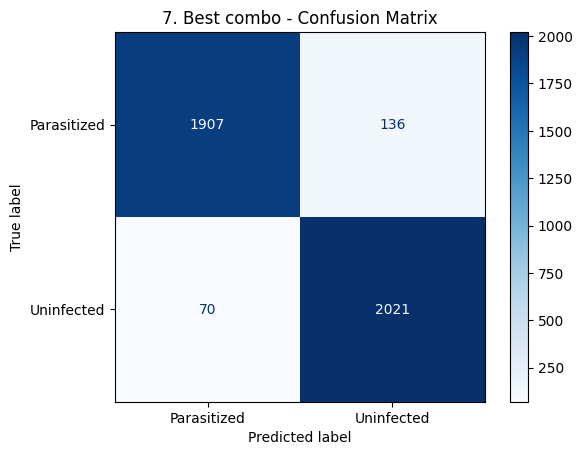

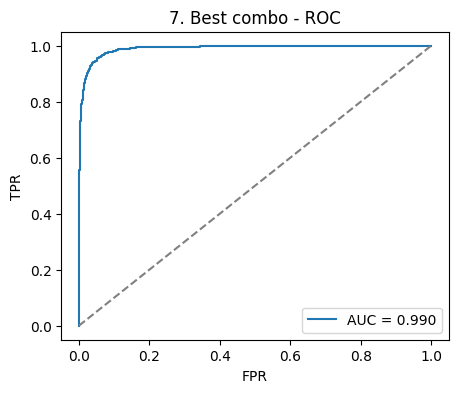


RESULTS TABLE:

       Experiment  Accuracy  Precision  Recall     F1    AUC
        1. Frozen    0.9359     0.9180  0.9589 0.9380 0.9820
2. + Augmentation    0.9156     0.8952  0.9436 0.9187 0.9735
 3. Lower LR 1e-4    0.8991     0.8605  0.9555 0.9055 0.9669
  4. Fine-tune 20    0.9456     0.9233  0.9732 0.9476 0.9887
  5. Fine-tune 40    0.9560     0.9462  0.9680 0.9570 0.9910
 6. + Dropout 0.4    0.9444     0.9220  0.9723 0.9465 0.9884
    7. Best combo    0.9502     0.9369  0.9665 0.9515 0.9899


,Experiment,Accuracy,Precision,Recall,F1,AUC
0,1. Frozen,0.9359,0.9180,0.9589,0.9380,0.9820
1,2. + Augmentation,0.9156,0.8952,0.9436,0.9187,0.9735
2,3. Lower LR 1e-4,0.8991,0.8605,0.9555,0.9055,0.9669
3,4. Fine-tune 20,0.9456,0.9233,0.9732,0.9476,0.9887
4,5. Fine-tune 40,0.9560,0.9462,0.9680,0.9570,0.9910
5,6. + Dropout 0.4,0.9444,0.9220,0.9723,0.9465,0.9884
6,7. Best combo,0.9502,0.9369,0.9665,0.9515,0.9899


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augment")

def build_mobilenet(augment=False, dropout=0.2, fine_tune_last=0):
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    if fine_tune_last == 0:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:-fine_tune_last]:
            layer.trainable = False
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs) if augment else inputs
    x = preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)

def train_and_evaluate(name, model, lr=1e-3, epochs=8):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                          restore_best_weights=True)
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=[es])
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_prob = model.predict(test_ds).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hist.history["loss"], label="train"); ax[0].plot(hist.history["val_loss"], label="val")
    ax[0].set_title(f"{name} - Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(hist.history["accuracy"], label="train"); ax[1].plot(hist.history["val_accuracy"], label="val")
    ax[1].set_title(f"{name} - Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(); plt.show()
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=class_names).plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix"); plt.show()
    plt.figure(figsize=(5, 4)); plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
    plt.plot([0, 1], [0, 1], "--", color="grey"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"{name} - ROC"); plt.legend(); plt.show()

    return {"Experiment": name,
            "Accuracy":  round(float(np.mean(y_pred == y_true)), 4),
            "Precision": round(precision_score(y_true, y_pred), 4),
            "Recall":    round(recall_score(y_true, y_pred), 4),
            "F1":        round(f1_score(y_true, y_pred), 4),
            "AUC":       round(auc(fpr, tpr), 4)}

configs = [
    ("1. Frozen",         dict(),                                             dict(lr=1e-3, epochs=8)),
    ("2. + Augmentation", dict(augment=True),                                 dict(lr=1e-3, epochs=8)),
    ("3. Lower LR 1e-4",  dict(augment=True),                                 dict(lr=1e-4, epochs=8)),
    ("4. Fine-tune 20",   dict(augment=True, fine_tune_last=20),              dict(lr=1e-5, epochs=8)),
    ("5. Fine-tune 40",   dict(augment=True, fine_tune_last=40),              dict(lr=1e-5, epochs=8)),
    ("6. + Dropout 0.4",  dict(augment=True, fine_tune_last=20, dropout=0.4), dict(lr=1e-5, epochs=8)),
    ("7. Best combo",     dict(augment=True, fine_tune_last=20, dropout=0.3), dict(lr=1e-5, epochs=12)),
]
rows = []
for name, build_kw, train_kw in configs:
    print("\n" + "="*55 + f"\n{name}\n" + "="*55)
    rows.append(train_and_evaluate(name, build_mobilenet(**build_kw), **train_kw))

mobilenet_df = pd.DataFrame(rows)
mobilenet_df.to_csv("mobilenetv2_results.csv", index=False)
print("\nRESULTS TABLE:\n"); print(mobilenet_df.to_string(index=False))
mobilenet_df

In [ ]:
import numpy as np
y_true = np.concatenate([y.numpy() for _, y in test_ds])
print("Test set label counts:", np.bincount(y_true.astype(int)))
print("Total test samples:", len(y_true))

Test set label counts: [2043 2091]
Total test samples: 4134


In [ ]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
print("Test set label counts:", np.bincount(y_true.astype(int)))

Test set label counts: [2043 2091]
